# Test run on amoc reconstruction using lagged PC's

### Used models: IPSL


In [3]:
#!/usr/bin/env python3
"""
AMOC RECONSTRUCTION MODEL
-------------------------

Reconstructs AMOC using:
  - Temperature EOF PCs
  - Salinity EOF PCs
  - Lagged feature matrix (50 years)
  - Ridge Regression

Works for IPSL and MPI.

Produces:
  - X_test, Y_true, Y_pred, model coefficients
  - R² score on test set
"""

import numpy as np
import xarray as xr
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# ============================================================
# USER CONFIG
# ============================================================
MODEL = "IPSL-CM6A-LR"        # ← choose: "IPSL-CM6A-LR", "MPI-ESM1-2-LR"
DEPTH_LABEL = "0-1000m"       # depth-mean EOF label
N_LAGS = 50
N_MODES = 10
TARGET = "AMOC_26N_ensmean"           # or "AMOC_45N_ensmean"

BASE_EOF = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/combined_depthmeans"
PC_FILE_T = f"{BASE_EOF}/EOF_combined_thetao_depthmean_{DEPTH_LABEL}.nc"
PC_FILE_S = f"{BASE_EOF}/EOF_combined_so_depthmean_{DEPTH_LABEL}.nc"

AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

OUT_PREFIX = f"/data/users/frekle/AMOC_reconstruction/{MODEL}_{TARGET}_{DEPTH_LABEL}"
# ============================================================


# ============================================================
# 1. LOAD PC DATA
# ============================================================
print(f"\n=== Loading PCs for {MODEL} ({DEPTH_LABEL}) ===")

dsT = xr.open_dataset(PC_FILE_T)
dsS = xr.open_dataset(PC_FILE_S)

# PC dims: (member, time, mode)
PC_T = dsT["PC"].mean("member").isel(mode=slice(0, N_MODES))   # (time, mode)
PC_S = dsS["PC"].mean("member").isel(mode=slice(0, N_MODES))

# Align time
common_time = np.intersect1d(PC_T["time"], PC_S["time"])
PC_T = PC_T.sel(time=common_time)
PC_S = PC_S.sel(time=common_time)

PC_T_np = PC_T.values
PC_S_np = PC_S.values
T = PC_T_np.shape[0]

print(f"→ Common time steps: {T}")


# ============================================================
# 2. LOAD AMOC INDEX
# ============================================================
print("\n=== Loading AMOC index ===")
dsA = xr.open_dataset(AMOC_FILE)

AMOC = dsA[TARGET].sel(time=common_time).values
print(f"→ AMOC length: {AMOC.shape[0]}")


# ============================================================
# 3. BUILD LAGGED FEATURE MATRIX
# ============================================================
print("\n=== Building lagged feature matrix ===")
# feature dimension = N_LAGS * (N_MODES * 2)
X_list, Y_list = [], []

for t in range(N_LAGS, T):
    feats = []
    for lag in range(N_LAGS):
        tt = t - lag
        feats.extend(PC_T_np[tt, :])    # temperature modes
        feats.extend(PC_S_np[tt, :])    # salinity modes
    X_list.append(feats)
    Y_list.append(AMOC[t])

X = np.array(X_list)   # shape (T - N_LAGS, features)
Y = np.array(Y_list)

print("→ Feature matrix shape:", X.shape)
print("→ Target shape:", Y.shape)


# ============================================================
# 4. TRAIN / TEST SPLIT
# ============================================================
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
Y_train, Y_test = Y[:split], Y[split:]

print(f"\nTrain samples: {len(X_train)}, Test samples: {len(X_test)}")


# ============================================================
# 5. FIT RIDGE REGRESSION
# ============================================================
print("\n=== Training Ridge regression model ===")
model = Ridge(alpha=1.0)
model.fit(X_train, Y_train)

Y_pred = model.predict(X_test)
r2 = r2_score(Y_test, Y_pred)

print(f"\n📈 R² score on test set: {r2:.3f}")


# ============================================================
# 6. SAVE RESULTS
# ============================================================
print("\n=== Saving output ===")

np.save(OUT_PREFIX + "_Xtest.npy", X_test)
np.save(OUT_PREFIX + "_Ytest_true.npy", Y_test)
np.save(OUT_PREFIX + "_Ytest_pred.npy", Y_pred)
np.save(OUT_PREFIX + "_weights.npy", model.coef_)

print(f"\nSaved reconstruction results to:\n  {OUT_PREFIX}_*.npy\n")
print("🎉 DONE — AMOC reconstruction complete!\n")



=== Loading PCs for IPSL-CM6A-LR (0-1000m) ===
→ Common time steps: 165

=== Loading AMOC index ===


OSError: [Errno -101] NetCDF: HDF error: '/data/users/frekle/AMOC_analysis/AMOC_IPSL-CM6A-LR.nc'

/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'gini' loading failed:
cannot import name 'cartopy_utils' from partially initialized module 'metpy.plots' (most likely due to a circular import) (/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/metpy/plots/__init__.py)
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


Time axis length: 23
Y_test length: 23


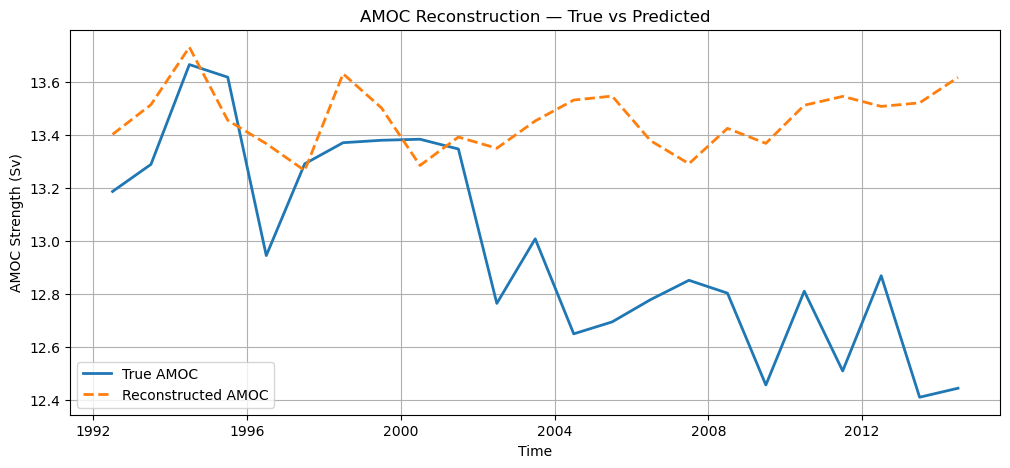

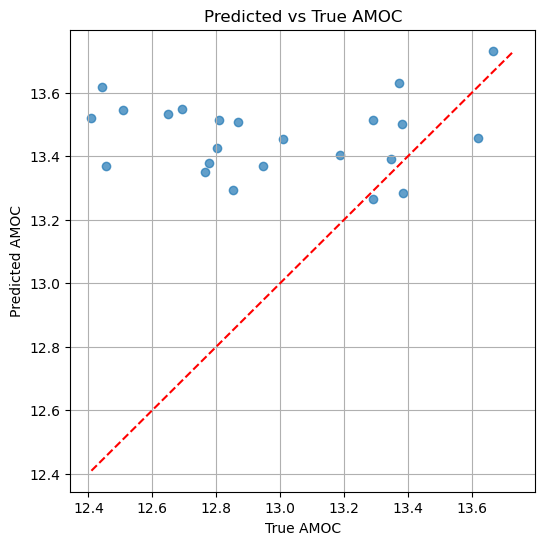

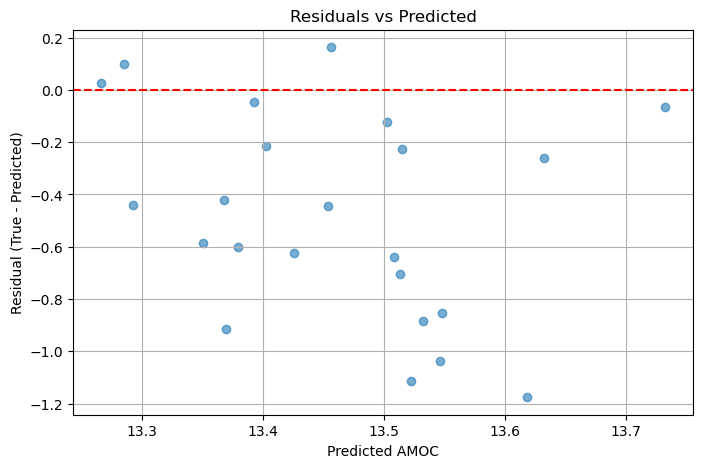

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

# ----------------------------
# LOAD reconstruction arrays
# ----------------------------
MODEL = "IPSL-CM6A-LR"
DEPTH_LABEL = "0-1000m"
TARGET = "AMOC_26N_ensmean"

BASE = f"/data/users/frekle/AMOC_reconstruction/{MODEL}_{TARGET}_{DEPTH_LABEL}"

Y_test = np.load(BASE + "_Ytest_true.npy")
Y_pred = np.load(BASE + "_Ytest_pred.npy")

# ----------------------------
# REBUILD TIME AXIS
# ----------------------------
PC_FILE_THETAO = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/combined_depthmeans/EOF_combined_thetao_depthmean_{DEPTH_LABEL}.nc"
ds_PC = xr.open_dataset(PC_FILE_THETAO)

N_LAGS = 50  # must match reconstruction script

# Full original time axis
full_time = ds_PC["time"].values

# Remove the first N_LAGS entries (used for lag construction)
usable_time = full_time[N_LAGS:]

# Split point (same as training/testing)
split = int(0.8 * len(usable_time))

# Test time values
time_test = usable_time[split:]

print("Time axis length:", len(time_test))
print("Y_test length:", len(Y_test))

# Ensure correct shapes
Y_test = Y_test.flatten()
Y_pred = Y_pred.flatten()
time_test = time_test.flatten()

# -------------------------------
# 1. True vs Predicted Time Series
# -------------------------------
plt.figure(figsize=(12, 5))
plt.plot(time_test, Y_test, label="True AMOC", lw=2)
plt.plot(time_test, Y_pred, label="Reconstructed AMOC", lw=2, linestyle="--")
plt.legend()
plt.xlabel("Time")
plt.ylabel("AMOC Strength (Sv)")
plt.title("AMOC Reconstruction — True vs Predicted")
plt.grid()
plt.show()

# -------------------------------
# 2. True vs Predicted Scatter
# -------------------------------
plt.figure(figsize=(6,6))
plt.scatter(Y_test, Y_pred, alpha=0.7)
plt.xlabel("True AMOC")
plt.ylabel("Predicted AMOC")
plt.title("Predicted vs True AMOC")
plt.grid()

# 1:1 line
lims = [min(Y_test.min(), Y_pred.min()), max(Y_test.max(), Y_pred.max())]
plt.plot(lims, lims, 'r--')
plt.show()

# -------------------------------
# 3. Residual Plot
# -------------------------------
resid = Y_test - Y_pred

plt.figure(figsize=(8,5))
plt.scatter(Y_pred, resid, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted AMOC")
plt.ylabel("Residual (True - Predicted)")
plt.title("Residuals vs Predicted")
plt.grid()
plt.show()



In [ ]:
print("Shapes:")
print("Y_test:", Y_test.shape)
print("Y_pred:", Y_pred.shape)
print("time_test:", time_test.shape)


Shapes:
Y_test: (23, 1)
Y_pred: (23,)
time_test: (23,)


## Fewer lag years and excluding industrial period

In [ ]:
#!/usr/bin/env python3
"""
AMOC RECONSTRUCTION — ENSEMBLE MEAN
-----------------------------------

Reconstructs AMOC (ensemble-mean) using:

  • Temperature EOF PCs (thetao)
  • Salinity EOF PCs (so)
  • 50-year lagged features of both
  • Ridge regression (linear, regularized)

Inputs:
  - EOF_combined_thetao_depthmean_{DEPTH_LABEL}.nc
  - EOF_combined_so_depthmean_{DEPTH_LABEL}.nc
  - AMOC_{MODEL}.nc   (with AMOC_26N_ensmean, AMOC_45N_ensmean, ...)

Output:
  - X_test, Y_test_true, Y_test_pred, time_test, model coefficients, R²
"""

import os
import numpy as np
import xarray as xr
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# ============================================================
# USER CONFIG
# ============================================================
MODEL       = "IPSL-CM6A-LR"        # "IPSL-CM6A-LR" or "MPI-ESM1-2-LR"
DEPTH_LABEL = "0-1000m"            # depth-mean label from your EOF files
N_MODES     = 50                   # number of EOF modes to use (per variable)
N_LAGS      = 10                   # number of lag years
TARGET      = "AMOC_45N_ensmean"   # or "AMOC_45N_ensmean"
TEST_FRAC   = 0.2                  # 20% of samples as test set

# Paths
BASE_EOF    = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/combined_depthmeans"
PC_FILE_T   = f"{BASE_EOF}/EOF_combined_thetao_depthmean_{DEPTH_LABEL}.nc"
PC_FILE_S   = f"{BASE_EOF}/EOF_combined_so_depthmean_{DEPTH_LABEL}.nc"
AMOC_FILE   = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

OUT_PREFIX  = f"/data/users/frekle/AMOC_reconstruction/{MODEL}_{TARGET}_{DEPTH_LABEL}_TL{N_LAGS}"
os.makedirs(os.path.dirname(OUT_PREFIX), exist_ok=True)

# ============================================================
# 1. LOAD PC DATA (TEMP + SAL), ENSEMBLE MEANS
# ============================================================
print(f"\n=== Loading PCs for {MODEL}, depth {DEPTH_LABEL} ===")

dsT = xr.open_dataset(PC_FILE_T)
dsS = xr.open_dataset(PC_FILE_S)

# PCs: (member, time, mode) → ensemble mean over member
PC_T = dsT["PC"].isel(mode=slice(0, N_MODES)).mean("member")  # (time, mode)
PC_S = dsS["PC"].isel(mode=slice(0, N_MODES)).mean("member")  # (time, mode)

# Align time between T and S
common_time = np.intersect1d(PC_T["time"].values, PC_S["time"].values)
PC_T = PC_T.sel(time=common_time)
PC_S = PC_S.sel(time=common_time)

PC_T_np = PC_T.values  # (T, N_MODES)
PC_S_np = PC_S.values  # (T, N_MODES)
T = PC_T_np.shape[0]

print(f"→ Common time steps (PCs): {T}")

# ============================================================
# 2. LOAD AMOC INDEX (ENSEMBLE MEAN)
# ============================================================
print("\n=== Loading AMOC ensemble-mean index ===")

dsA = xr.open_dataset(AMOC_FILE)
AMOC_da = dsA[TARGET]

# Align AMOC time with PC time
common_time2 = np.intersect1d(common_time, AMOC_da["time"].values)
PC_T = PC_T.sel(time=common_time2)
PC_S = PC_S.sel(time=common_time2)
AMOC_da = AMOC_da.sel(time=common_time2)

time = AMOC_da["time"].values
AMOC = AMOC_da.values  # (T,)

# ============================================================
# LIMIT TRAINING WINDOW (IMPORTANT!)
# ============================================================
YEAR_MIN = 1850
YEAR_MAX = 1960   # ← CHANGE THIS IF YOU WANT A DIFFERENT WINDOW

years = PC_T["time"].dt.year.values
mask = (years >= YEAR_MIN) & (years <= YEAR_MAX)

print(f"\nRestricting training period to {YEAR_MIN}–{YEAR_MAX}")
print(f"→ Keeping {mask.sum()} time steps")

PC_T = PC_T.sel(time=PC_T["time"][mask])
PC_S = PC_S.sel(time=PC_S["time"][mask])

# Apply same mask to AMOC
AMOC = dsA[TARGET].sel(time=common_time)[mask].values

# Convert to numpy
PC_T_np = PC_T.values
PC_S_np = PC_S.values

years_sel = PC_T["time"].values
T = len(years_sel)

print(f"→ Final usable time steps: {T}")


# ============================================================
# 3. BUILD LAGGED FEATURE MATRIX
# ============================================================
print("\n=== Building lagged feature matrix ===")
print(f"Using N_LAGS = {N_LAGS}, N_MODES = {N_MODES}")

# Each sample at time t uses:
#   [PC_T(t), PC_S(t),
#    PC_T(t-1), PC_S(t-1),
#    ...
#    PC_T(t-(N_LAGS-1)), PC_S(t-(N_LAGS-1))]
#
# Feature dimension = N_LAGS * (2 * N_MODES)

X_list = []
Y_list = []
time_list = []

for t in range(N_LAGS, T):
    feats = []
    for lag in range(N_LAGS):
        tt = t - lag
        feats.extend(PC_T_np[tt, :])  # temp PCs
        feats.extend(PC_S_np[tt, :])  # sal PCs
    X_list.append(feats)
    Y_list.append(AMOC[t])
    time_list.append(time[t])

X = np.array(X_list)      # (T - N_LAGS, N_LAGS * 2 * N_MODES)
Y = np.array(Y_list)      # (T - N_LAGS,)
time_samples = np.array(time_list)

print("→ Feature matrix shape:", X.shape)
print("→ Target shape:", Y.shape)
print("→ Sample time axis length:", time_samples.shape)

# ============================================================
# 4. TRAIN / TEST SPLIT
# ============================================================
n_samples = X.shape[0]
n_train = int((1.0 - TEST_FRAC) * n_samples)

X_train, X_test = X[:n_train], X[n_train:]
Y_train, Y_test = Y[:n_train], Y[n_train:]
time_train, time_test = time_samples[:n_train], time_samples[n_train:]

print(f"\nTrain samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

# ============================================================
# 5. FIT RIDGE REGRESSION
# ============================================================
print("\n=== Fitting Ridge regression model ===")

model = Ridge(alpha=1.0)   # you can tune alpha later if you want
model.fit(X_train, Y_train)

Y_pred = model.predict(X_test)
r2 = r2_score(Y_test, Y_pred)

print(f"\n📈 R² score on test set: {r2:.3f}")

# ============================================================
# 6. SAVE RESULTS
# ============================================================
print("\n=== Saving reconstruction outputs ===")

np.save(OUT_PREFIX + "_Xtest.npy", X_test)
np.save(OUT_PREFIX + "_Ytest_true.npy", Y_test)
np.save(OUT_PREFIX + "_Ytest_pred.npy", Y_pred)
np.save(OUT_PREFIX + "_time_test.npy", time_test)
np.save(OUT_PREFIX + "_weights.npy", model.coef_)
np.save(OUT_PREFIX + "_intercept.npy", np.array([model.intercept_]))
np.save(OUT_PREFIX + "_meta.npy",
        np.array([r2, N_LAGS, N_MODES], dtype=float))

print(f"\nSaved arrays with prefix:\n  {OUT_PREFIX}_*.npy")
print("🎉 DONE — AMOC reconstruction using temp + sal PCs complete!\n")



=== Loading PCs for IPSL-CM6A-LR, depth 0-1000m ===
→ Common time steps (PCs): 165

=== Loading AMOC ensemble-mean index ===

Restricting training period to 1850–1960
→ Keeping 111 time steps
→ Final usable time steps: 111

=== Building lagged feature matrix ===
Using N_LAGS = 10, N_MODES = 50
→ Feature matrix shape: (101, 200)
→ Target shape: (101, 1)
→ Sample time axis length: (101,)

Train samples: 80, Test samples: 21

=== Fitting Ridge regression model ===

📈 R² score on test set: 0.339

=== Saving reconstruction outputs ===

Saved arrays with prefix:
  /data/users/frekle/AMOC_reconstruction/IPSL-CM6A-LR_AMOC_45N_ensmean_0-1000m_TL10_*.npy
🎉 DONE — AMOC reconstruction using temp + sal PCs complete!




=== Loading reconstruction results ===
Loaded: 21 test samples


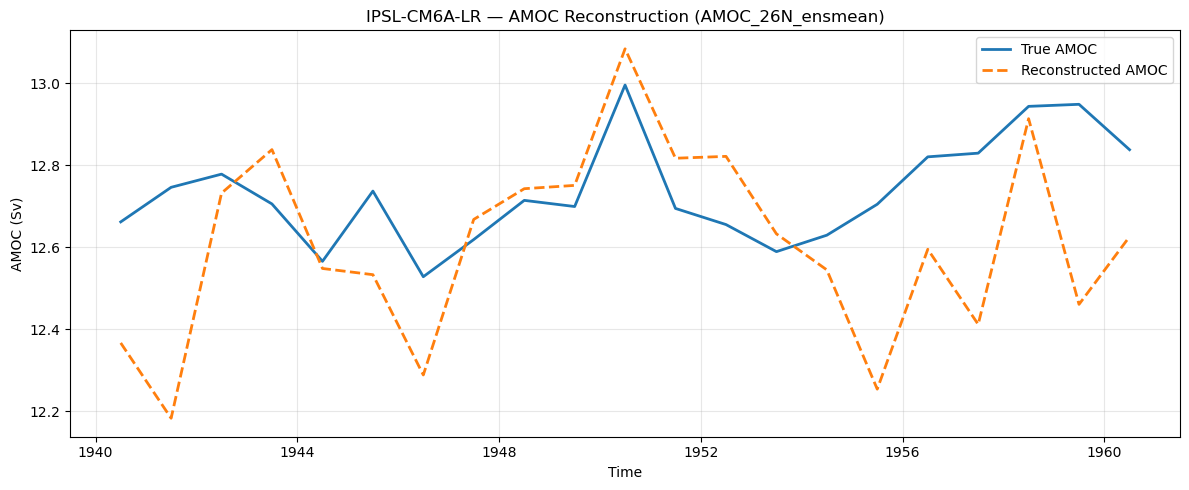

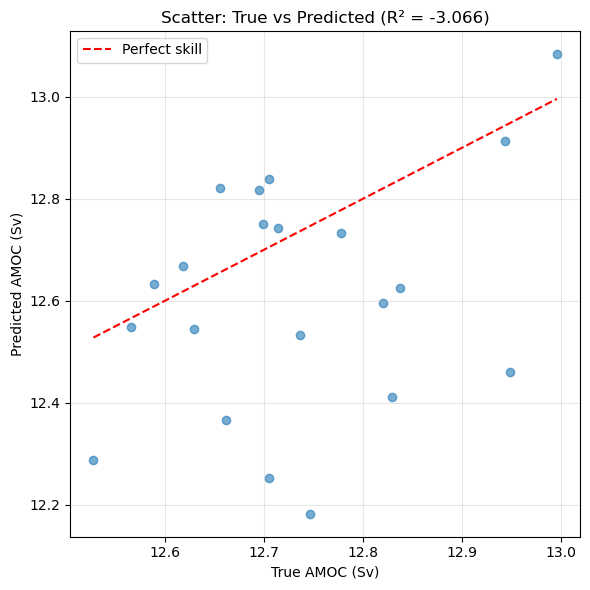

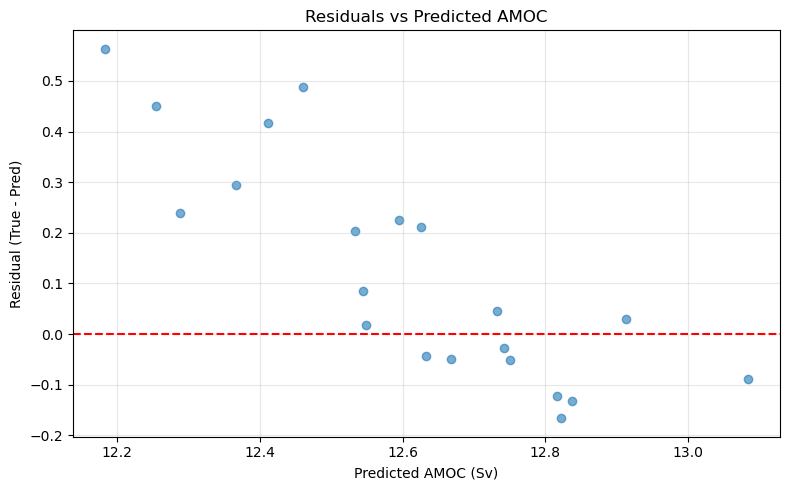

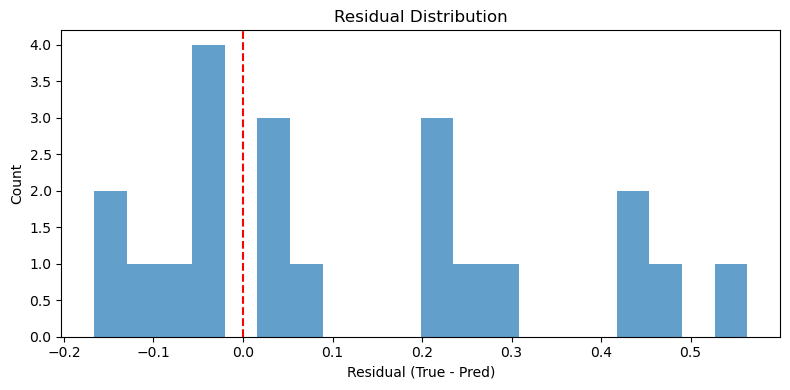


🎉 Finished plotting AMOC reconstruction results!



In [ ]:
#!/usr/bin/env python3
"""
PLOTTING SCRIPT — AMOC Reconstruction
-------------------------------------

Loads:
  - Ytest_true
  - Ytest_pred
  - time_test
  - model weights (optional)

Produces:
  1. AMOC time series: true vs reconstructed
  2. Scatter plot: predicted vs true AMOC
  3. Residual plot
  4. Histogram of residuals
"""

import numpy as np
import matplotlib.pyplot as plt
import os

# ============================================================
# USER CONFIG
# ============================================================
MODEL = "IPSL-CM6A-LR"
TARGET = "AMOC_26N_ensmean"
DEPTH_LABEL = "0-1000m"
N_LAGS = 10

PREFIX = f"/data/users/frekle/AMOC_reconstruction/IPSL-CM6A-LR_0-1000m_26N/{MODEL}_{TARGET}_{DEPTH_LABEL}_TL{N_LAGS}"

# ============================================================
# LOAD DATA
# ============================================================
print("\n=== Loading reconstruction results ===")

Y_true = np.load(PREFIX + "_Ytest_true.npy")        # shape (N,)
Y_pred = np.load(PREFIX + "_Ytest_pred.npy")        # shape (N,)
time_test = np.load(PREFIX + "_time_test.npy")      # shape (N,)
weights = np.load(PREFIX + "_weights.npy")          # ridge coefficients

print(f"Loaded: {len(Y_true)} test samples")

# Flatten if needed
Y_true = Y_true.reshape(-1)
Y_pred = Y_pred.reshape(-1)

# Residuals
resid = Y_true - Y_pred


# ============================================================
# 1. TRUE vs PREDICTED (TIME SERIES)
# ============================================================
plt.figure(figsize=(12, 5))
plt.plot(time_test, Y_true, label="True AMOC", lw=2)
plt.plot(time_test, Y_pred, label="Reconstructed AMOC", lw=2, linestyle="--")
plt.xlabel("Time")
plt.ylabel("AMOC (Sv)")
plt.title(f"{MODEL} — AMOC Reconstruction ({TARGET})")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PREFIX + "_timeseries_26N.png", dpi=300)
plt.show()


# ============================================================
# 2. TRUE vs PREDICTED (SCATTER)
# ============================================================
plt.figure(figsize=(6, 6))
plt.scatter(Y_true, Y_pred, alpha=0.6)
plt.plot([Y_true.min(), Y_true.max()],
         [Y_true.min(), Y_true.max()],
         'r--', label="Perfect skill")

# Compute correlation / R²
from sklearn.metrics import r2_score
r2 = r2_score(Y_true, Y_pred)

plt.xlabel("True AMOC (Sv)")
plt.ylabel("Predicted AMOC (Sv)")
plt.title(f"Scatter: True vs Predicted (R² = {r2:.3f})")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 3. RESIDUALS vs PREDICTED
# ============================================================
plt.figure(figsize=(8, 5))
plt.scatter(Y_pred, resid, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted AMOC (Sv)")
plt.ylabel("Residual (True - Pred)")
plt.title("Residuals vs Predicted AMOC")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 4. RESIDUAL HISTOGRAM
# ============================================================
plt.figure(figsize=(8, 4))
plt.hist(resid, bins=20, alpha=0.7)
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Residual (True - Pred)")
plt.ylabel("Count")
plt.title("Residual Distribution")
plt.tight_layout()
plt.show()

print("\n🎉 Finished plotting AMOC reconstruction results!\n")


In [ ]:
#!/usr/bin/env python3
"""
AMOC RECONSTRUCTION — ENSEMBLE MEAN
-----------------------------------

Reconstructs AMOC (ensemble-mean) using:

  • Temperature EOF PCs (thetao)
  • Salinity EOF PCs (so)
  • 50-year lagged features of both
  • Ridge regression (linear, regularized)

Inputs:
  - EOF_combined_thetao_depthmean_{DEPTH_LABEL}.nc
  - EOF_combined_so_depthmean_{DEPTH_LABEL}.nc
  - AMOC_{MODEL}.nc   (with AMOC_26N_ensmean, AMOC_45N_ensmean, ...)

Output:
  - X_test, Y_test_true, Y_test_pred, time_test, model coefficients, R²
"""

import os
import numpy as np
import xarray as xr
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# ============================================================
# USER CONFIG
# ============================================================
MODEL       = "MPI-ESM1-2-LR"        # "IPSL-CM6A-LR" or "MPI-ESM1-2-LR"
DEPTH_LABEL = "0-1000m"            # depth-mean label from your EOF files
N_MODES     = 50                   # number of EOF modes to use (per variable)
N_LAGS      = 10                   # number of lag years
TARGET      = "AMOC_26N_ensmean"   # or "AMOC_45N_ensmean"
TEST_FRAC   = 0.2                  # 20% of samples as test set

# Paths
BASE_EOF    = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/combined_depthmeans"
PC_FILE_T   = f"{BASE_EOF}/EOF_combined_thetao_depthmean_{DEPTH_LABEL}.nc"
PC_FILE_S   = f"{BASE_EOF}/EOF_combined_so_depthmean_{DEPTH_LABEL}.nc"
AMOC_FILE   = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

OUT_PREFIX  = f"/data/users/frekle/AMOC_reconstruction/{MODEL}_{TARGET}_{DEPTH_LABEL}_TL{N_LAGS}"
os.makedirs(os.path.dirname(OUT_PREFIX), exist_ok=True)

# ============================================================
# 1. LOAD PC DATA (TEMP + SAL), ENSEMBLE MEANS
# ============================================================
print(f"\n=== Loading PCs for {MODEL}, depth {DEPTH_LABEL} ===")

dsT = xr.open_dataset(PC_FILE_T)
dsS = xr.open_dataset(PC_FILE_S)

# PCs: (member, time, mode) → ensemble mean over member
PC_T = dsT["PC"].isel(mode=slice(0, N_MODES)).mean("member")  # (time, mode)
PC_S = dsS["PC"].isel(mode=slice(0, N_MODES)).mean("member")  # (time, mode)

# Align time between T and S
common_time = np.intersect1d(PC_T["time"].values, PC_S["time"].values)
PC_T = PC_T.sel(time=common_time)
PC_S = PC_S.sel(time=common_time)

PC_T_np = PC_T.values  # (T, N_MODES)
PC_S_np = PC_S.values  # (T, N_MODES)
T = PC_T_np.shape[0]

print(f"→ Common time steps (PCs): {T}")

# ============================================================
# 2. LOAD AMOC INDEX (ENSEMBLE MEAN)
# ============================================================
print("\n=== Loading AMOC ensemble-mean index ===")

dsA = xr.open_dataset(AMOC_FILE)
AMOC_da = dsA[TARGET]

# Align AMOC time with PC time
common_time2 = np.intersect1d(common_time, AMOC_da["time"].values)
PC_T = PC_T.sel(time=common_time2)
PC_S = PC_S.sel(time=common_time2)
AMOC_da = AMOC_da.sel(time=common_time2)

time = AMOC_da["time"].values
AMOC = AMOC_da.values  # (T,)

# ============================================================
# LIMIT TRAINING WINDOW (IMPORTANT!)
# ============================================================
YEAR_MIN = 1850
YEAR_MAX = 1960   # ← CHANGE THIS IF YOU WANT A DIFFERENT WINDOW

years = PC_T["time"].dt.year.values
mask = (years >= YEAR_MIN) & (years <= YEAR_MAX)

print(f"\nRestricting training period to {YEAR_MIN}–{YEAR_MAX}")
print(f"→ Keeping {mask.sum()} time steps")

PC_T = PC_T.sel(time=PC_T["time"][mask])
PC_S = PC_S.sel(time=PC_S["time"][mask])

# Apply same mask to AMOC
AMOC = dsA[TARGET].sel(time=common_time)[mask].values

# Convert to numpy
PC_T_np = PC_T.values
PC_S_np = PC_S.values

years_sel = PC_T["time"].values
T = len(years_sel)

print(f"→ Final usable time steps: {T}")


# ============================================================
# 3. BUILD LAGGED FEATURE MATRIX
# ============================================================
print("\n=== Building lagged feature matrix ===")
print(f"Using N_LAGS = {N_LAGS}, N_MODES = {N_MODES}")

# Each sample at time t uses:
#   [PC_T(t), PC_S(t),
#    PC_T(t-1), PC_S(t-1),
#    ...
#    PC_T(t-(N_LAGS-1)), PC_S(t-(N_LAGS-1))]
#
# Feature dimension = N_LAGS * (2 * N_MODES)

X_list = []
Y_list = []
time_list = []

for t in range(N_LAGS, T):
    feats = []
    for lag in range(N_LAGS):
        tt = t - lag
        feats.extend(PC_T_np[tt, :])  # temp PCs
        feats.extend(PC_S_np[tt, :])  # sal PCs
    X_list.append(feats)
    Y_list.append(AMOC[t])
    time_list.append(time[t])

X = np.array(X_list)      # (T - N_LAGS, N_LAGS * 2 * N_MODES)
Y = np.array(Y_list)      # (T - N_LAGS,)
time_samples = np.array(time_list)

print("→ Feature matrix shape:", X.shape)
print("→ Target shape:", Y.shape)
print("→ Sample time axis length:", time_samples.shape)

# ============================================================
# 4. TRAIN / TEST SPLIT
# ============================================================
n_samples = X.shape[0]
n_train = int((1.0 - TEST_FRAC) * n_samples)

X_train, X_test = X[:n_train], X[n_train:]
Y_train, Y_test = Y[:n_train], Y[n_train:]
time_train, time_test = time_samples[:n_train], time_samples[n_train:]

print(f"\nTrain samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

# ============================================================
# 5. FIT RIDGE REGRESSION
# ============================================================
print("\n=== Fitting Ridge regression model ===")

model = Ridge(alpha=1.0)   # you can tune alpha later if you want
model.fit(X_train, Y_train)

Y_pred = model.predict(X_test)
r2 = r2_score(Y_test, Y_pred)

print(f"\n📈 R² score on test set: {r2:.3f}")

# ============================================================
# 6. SAVE RESULTS
# ============================================================
print("\n=== Saving reconstruction outputs ===")

np.save(OUT_PREFIX + "_Xtest.npy", X_test)
np.save(OUT_PREFIX + "_Ytest_true.npy", Y_test)
np.save(OUT_PREFIX + "_Ytest_pred.npy", Y_pred)
np.save(OUT_PREFIX + "_time_test.npy", time_test)
np.save(OUT_PREFIX + "_weights.npy", model.coef_)
np.save(OUT_PREFIX + "_intercept.npy", np.array([model.intercept_]))
np.save(OUT_PREFIX + "_meta.npy",
        np.array([r2, N_LAGS, N_MODES], dtype=float))

print(f"\nSaved arrays with prefix:\n  {OUT_PREFIX}_*.npy")
print("🎉 DONE — AMOC reconstruction using temp + sal PCs complete!\n")



=== Loading PCs for MPI-ESM1-2-LR, depth 0-1000m ===


/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'gini' loading failed:
cannot import name 'cartopy_utils' from partially initialized module 'metpy.plots' (most likely due to a circular import) (/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/metpy/plots/__init__.py)
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


→ Common time steps (PCs): 165

=== Loading AMOC ensemble-mean index ===

Restricting training period to 1850–1960
→ Keeping 111 time steps
→ Final usable time steps: 111

=== Building lagged feature matrix ===
Using N_LAGS = 10, N_MODES = 50
→ Feature matrix shape: (101, 200)
→ Target shape: (101,)
→ Sample time axis length: (101,)

Train samples: 80, Test samples: 21

=== Fitting Ridge regression model ===

📈 R² score on test set: -4.527

=== Saving reconstruction outputs ===

Saved arrays with prefix:
  /data/users/frekle/AMOC_reconstruction/MPI-ESM1-2-LR_AMOC_26N_ensmean_0-1000m_TL10_*.npy
🎉 DONE — AMOC reconstruction using temp + sal PCs complete!




=== Loading reconstruction results ===
Loaded: 21 test samples


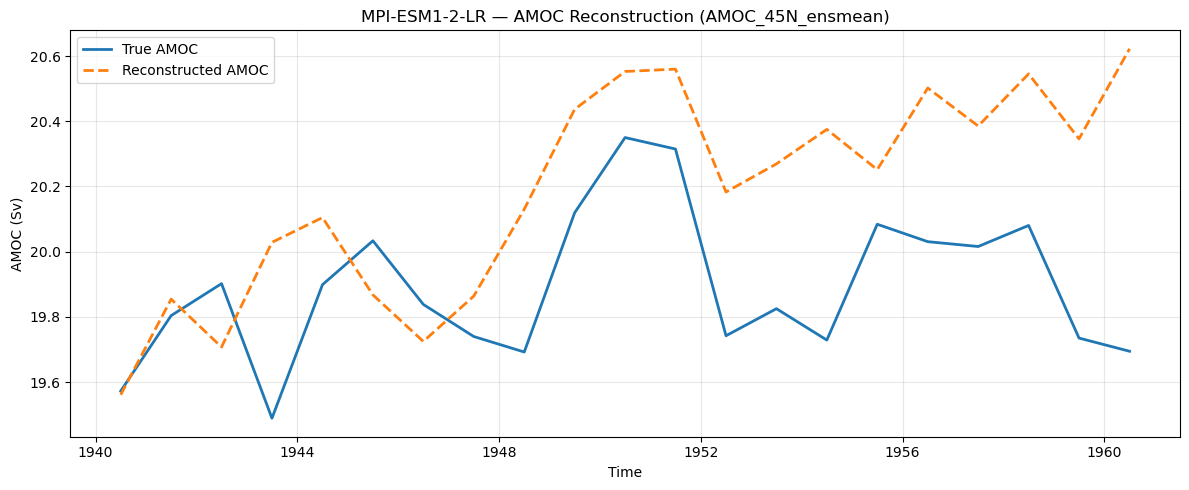

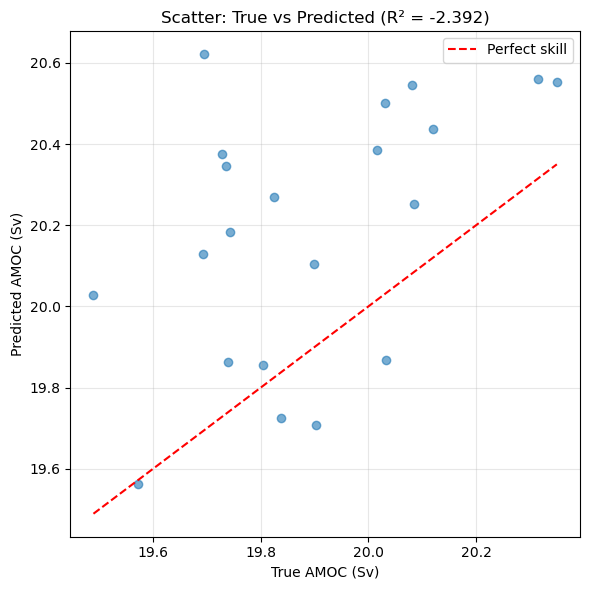

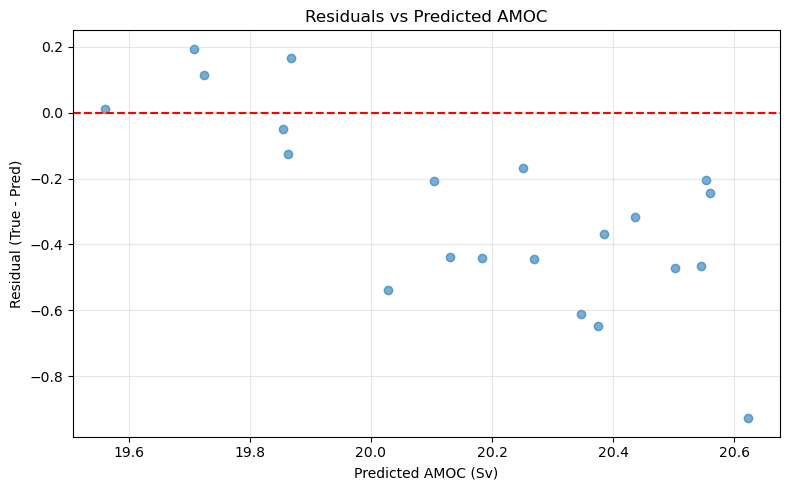

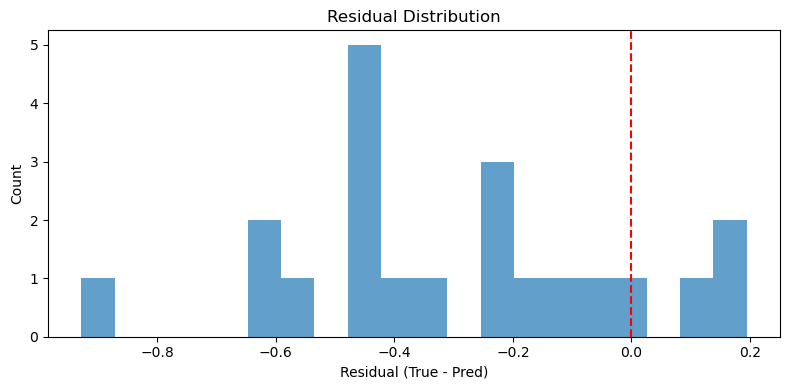


🎉 Finished plotting AMOC reconstruction results!



In [ ]:
#!/usr/bin/env python3
"""
PLOTTING SCRIPT — AMOC Reconstruction
-------------------------------------

Loads:
  - Ytest_true
  - Ytest_pred
  - time_test
  - model weights (optional)

Produces:
  1. AMOC time series: true vs reconstructed
  2. Scatter plot: predicted vs true AMOC
  3. Residual plot
  4. Histogram of residuals
"""

import numpy as np
import matplotlib.pyplot as plt
import os

# ============================================================
# USER CONFIG
# ============================================================
MODEL = "MPI-ESM1-2-LR"
TARGET = "AMOC_45N_ensmean"
DEPTH_LABEL = "0-1000m"
N_LAGS = 10

PREFIX = f"/data/users/frekle/AMOC_reconstruction/MPI-ESM1-2-LR_0-1000m_45N/{MODEL}_{TARGET}_{DEPTH_LABEL}_TL{N_LAGS}"
# ============================================================
# LOAD DATA
# ============================================================
print("\n=== Loading reconstruction results ===")

Y_true = np.load(PREFIX + "_Ytest_true.npy")        # shape (N,)
Y_pred = np.load(PREFIX + "_Ytest_pred.npy")        # shape (N,)
time_test = np.load(PREFIX + "_time_test.npy")      # shape (N,)
weights = np.load(PREFIX + "_weights.npy")          # ridge coefficients

print(f"Loaded: {len(Y_true)} test samples")

# Flatten if needed
Y_true = Y_true.reshape(-1)
Y_pred = Y_pred.reshape(-1)

# Residuals
resid = Y_true - Y_pred


# ============================================================
# 1. TRUE vs PREDICTED (TIME SERIES)
# ============================================================
plt.figure(figsize=(12, 5))
plt.plot(time_test, Y_true, label="True AMOC", lw=2)
plt.plot(time_test, Y_pred, label="Reconstructed AMOC", lw=2, linestyle="--")
plt.xlabel("Time")
plt.ylabel("AMOC (Sv)")
plt.title(f"{MODEL} — AMOC Reconstruction ({TARGET})")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PREFIX + "_timeseries_45N.png", dpi=300)
plt.show()


# ============================================================
# 2. TRUE vs PREDICTED (SCATTER)
# ============================================================
plt.figure(figsize=(6, 6))
plt.scatter(Y_true, Y_pred, alpha=0.6)
plt.plot([Y_true.min(), Y_true.max()],
         [Y_true.min(), Y_true.max()],
         'r--', label="Perfect skill")

# Compute correlation / R²
from sklearn.metrics import r2_score
r2 = r2_score(Y_true, Y_pred)

plt.xlabel("True AMOC (Sv)")
plt.ylabel("Predicted AMOC (Sv)")
plt.title(f"Scatter: True vs Predicted (R² = {r2:.3f})")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 3. RESIDUALS vs PREDICTED
# ============================================================
plt.figure(figsize=(8, 5))
plt.scatter(Y_pred, resid, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted AMOC (Sv)")
plt.ylabel("Residual (True - Pred)")
plt.title("Residuals vs Predicted AMOC")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 4. RESIDUAL HISTOGRAM
# ============================================================
plt.figure(figsize=(8, 4))
plt.hist(resid, bins=20, alpha=0.7)
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Residual (True - Pred)")
plt.ylabel("Count")
plt.title("Residual Distribution")
plt.tight_layout()
plt.show()

print("\n🎉 Finished plotting AMOC reconstruction results!\n")


### Lat_depth amoc reconstruction

##### Only thetao

In [2]:
#!/usr/bin/env python3
"""
AMOC RECONSTRUCTION — LAT–DEPTH EOFs (30°W, single variable)
------------------------------------------------------------

Reconstructs AMOC (ensemble mean) using:

  • Lat–depth EOF PCs at fixed longitude (30°W)
  • One variable (thetao OR so)
  • Lagged PC features
  • Ridge regression

IDENTICAL setup to the two-variable script, except for input features.

Calendar-safe: aligns PCs and AMOC by YEAR (not raw timestamps).
"""

import os
import numpy as np
import xarray as xr
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# USER CONFIG
# ============================================================

MODEL   = "IPSL-CM6A-LR"  # "IPSL-CM6A-LR" OR "MPI-ESM1-2-LR"
VAR     = "thetao"          # thetao OR so
LON_TAG = "W30p0"

N_MODES   = 10
N_LAGS    = 10
TARGET    = "AMOC_45N_ensmean"
TEST_FRAC = 0.2

# ============================================================
# PATHS
# ============================================================

EOF_FILE = (
    f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/"
    f"EOF_latdepth_{VAR}_{LON_TAG}.nc"
)

AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

OUTDIR = (
    f"/data/users/frekle/AMOC_reconstruction/Lat_depth/"
    f"{TARGET}/{MODEL}/{VAR}/"
)
os.makedirs(OUTDIR, exist_ok=True)

OUT_PREFIX = (
    f"{OUTDIR}/{MODEL}_{VAR}_{TARGET}_latdepth_{LON_TAG}_"
    f"T{N_MODES}_L{N_LAGS}"
)

# ============================================================
# TIME HANDLING (ROBUST)
# ============================================================

def extract_years(time_da, reference_years=None):
    vals = time_da.values

    # numpy datetime64
    if np.issubdtype(vals.dtype, np.datetime64):
        return np.array(
            [v.astype("datetime64[Y]").astype(int) + 1970 for v in vals],
            dtype=int
        )

    # cftime objects
    if len(vals) > 0 and hasattr(vals[0], "year"):
        return np.array([v.year for v in vals], dtype=int)

    # numeric CF-time
    if "units" in time_da.attrs:
        import cftime
        dates = cftime.num2date(
            vals,
            units=time_da.attrs["units"],
            calendar=time_da.attrs.get("calendar", "standard")
        )
        return np.array([d.year for d in dates], dtype=int)

    # index-like numeric
    if reference_years is not None:
        return np.array(reference_years, dtype=int)

    raise ValueError("Unsupported time format")

# ============================================================
# 1. LOAD EOF PCs
# ============================================================

print(f"\n=== Loading EOF PCs ({MODEL}, {VAR}, {LON_TAG}) ===")

ds_eof = xr.open_dataset(EOF_FILE)

PC = ds_eof["PC"].isel(mode=slice(0, N_MODES)).mean("member")
PC_years = extract_years(PC["time"])
PC_np = PC.values

print("PC shape:", PC_np.shape)

# ============================================================
# 2. LOAD AMOC
# ============================================================

print("\n=== Loading AMOC ===")

ds_amoc = xr.open_dataset(AMOC_FILE)
AMOC_da = ds_amoc[TARGET]

AMOC_years = extract_years(
    AMOC_da["time"],
    reference_years=PC_years
)
AMOC_np = AMOC_da.values

# ============================================================
# 3. ALIGN BY YEAR (ALL YEARS)
# ============================================================

common_years = np.intersect1d(PC_years, AMOC_years)

PC = PC.isel(time=np.isin(PC_years, common_years))
AMOC = AMOC_np[np.isin(AMOC_years, common_years)]
years = common_years

PC_np = PC.values
T = len(years)

print(f"✓ Aligned on {years[0]}–{years[-1]} ({T} years)")

# ============================================================
# 4. BUILD LAGGED FEATURE MATRIX
# ============================================================

print("\n=== Building lagged feature matrix ===")

X, Y, time_out = [], [], []

for t in range(N_LAGS, T):
    feats = []
    for lag in range(N_LAGS):
        feats.extend(PC_np[t - lag])
    X.append(feats)
    Y.append(AMOC[t])
    time_out.append(years[t])

X = np.asarray(X)
Y = np.asarray(Y)
time_out = np.asarray(time_out)

print("Feature matrix:", X.shape)

# ============================================================
# 5. TRAIN / TEST SPLIT
# ============================================================

n_train = int((1 - TEST_FRAC) * len(X))

X_train, X_test = X[:n_train], X[n_train:]
Y_train, Y_test = Y[:n_train], Y[n_train:]
time_test = time_out[n_train:]

# ============================================================
# 6. RIDGE REGRESSION
# ============================================================

model = Ridge(alpha=1.0)
model.fit(X_train, Y_train)

Y_pred = model.predict(X_test)
r2 = r2_score(Y_test, Y_pred)

print(f"📈 R² = {r2:.3f}")

# ============================================================
# 7. SAVE OUTPUTS (MATCH TWO-VARIABLE FORMAT)
# ============================================================

np.save(OUT_PREFIX + "_Xtest.npy", X_test)
np.save(OUT_PREFIX + "_Ytest_true.npy", Y_test)
np.save(OUT_PREFIX + "_Ytest_pred.npy", Y_pred)
np.save(OUT_PREFIX + "_time_test.npy", time_test)
np.save(OUT_PREFIX + "_weights.npy", model.coef_)
np.save(OUT_PREFIX + "_intercept.npy", np.array([model.intercept_]))
np.save(OUT_PREFIX + "_meta.npy",
        np.array([r2, N_LAGS, N_MODES], dtype=float))

print("\n✅ DONE — single-variable reconstruction (all years)")



=== Loading EOF PCs (IPSL-CM6A-LR, thetao, W30p0) ===
PC shape: (165, 10)

=== Loading AMOC ===
✓ Aligned on 1850–2014 (165 years)

=== Building lagged feature matrix ===
Feature matrix: (155, 100)
📈 R² = -5.534

✅ DONE — single-variable reconstruction (all years)


### NEW

In [ ]:
#!/usr/bin/env python3
"""
AMOC RECONSTRUCTION — LAT–DEPTH EOFs (single variable)
------------------------------------------------------
Single-variable version of the multivariate reconstruction script.

Uses:
  • Lat–depth EOF PCs at fixed longitude (e.g. 30°W)
  • One variable (thetao OR so)
  • Lagged PC features
  • Ridge regression with:
      - StandardScaler
      - alpha scan
  • Robust YEAR alignment (year coordinate)
  • Optional amplitude calibration (TRAIN-only; no leakage)

Saves outputs in the same "new multivariate" format:
  _Ytrue.npy, _Ypred.npy (maybe calibrated), _Ypred_raw.npy, _time.npy,
  _coef.npy, _meta.npy, (_calibration_ab.npy)
"""

import os
import numpy as np
import xarray as xr

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import r2_score

# ============================================================
# CONFIG
# ============================================================

MODEL   = "IPSL-CM6A-LR"   # "IPSL-CM6A-LR", "MPI-ESM1-2-LR", "EC-Earth3", ...
VAR     = "thetao"         # "thetao" or "so"
LON_TAG = "W30p0"

N_MODES   = 10
N_LAGS    = 10
TARGET    = "AMOC_45N_ensmean"
TEST_FRAC = 0.2

# Ridge regularization scan
ALPHAS = [0.1, 1, 10, 100, 1000, 1e4, 1e5]

# Calibration: ONLY useful when corr is high but R² is poor (scale mismatch)
CALIBRATE_AMPLITUDE = False
CALIBRATE_IF = dict(min_corr=0.7, max_r2=0.2)  # auto-skip unless needed

EOF_FILE = (
    f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/"
    f"EOF_latdepth_{VAR}_{LON_TAG}.nc"
)
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

OUTDIR = f"/data/users/frekle/AMOC_reconstruction/Lat_depth/{TARGET}/{MODEL}/{VAR}/"
os.makedirs(OUTDIR, exist_ok=True)

# ============================================================
# HELPERS
# ============================================================

def extract_years(time_coord):
    """Robust year extraction from xarray time coordinate."""
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def build_lagged_matrix(PC_np, AMOC_1d, years, n_lags):
    X, Y, t_out = [], [], []
    T = len(years)
    for t in range(n_lags, T):
        feats = []
        for lag in range(n_lags):
            feats.extend(PC_np[t - lag])
        X.append(feats)
        Y.append(AMOC_1d[t])
        t_out.append(years[t])
    return np.asarray(X), np.asarray(Y).squeeze(), np.asarray(t_out)

def metrics(y_true, y_pred, label=""):
    y_true = np.asarray(y_true).squeeze()
    y_pred = np.asarray(y_pred).squeeze()
    r2 = float(r2_score(y_true, y_pred))
    r  = float(np.corrcoef(y_true, y_pred)[0, 1]) if (np.std(y_true) > 0 and np.std(y_pred) > 0) else np.nan
    mae  = float(np.mean(np.abs(y_true - y_pred)))
    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    if label:
        print(f"\n--- {label} ---")
    print(f"R²   = {r2:.4f}")
    print(f"corr = {r:.4f}")
    print(f"MAE  = {mae:.4f}")
    print(f"RMSE = {rmse:.4f}")
    return r2, r, mae, rmse

# ============================================================
# LOAD EOF PCs
# ============================================================

print("Loading EOF PCs...")
dsE = xr.open_dataset(EOF_FILE)

PC = dsE["PC"].isel(mode=slice(0, N_MODES))
if "member" in PC.dims:
    PC = PC.mean("member")

PC = PC.transpose("time", "mode")
PC_years = extract_years(PC["time"])

# ============================================================
# LOAD AMOC
# ============================================================

print("Loading AMOC...")
dsA = xr.open_dataset(AMOC_FILE)

AMOC_da = dsA[TARGET].squeeze()
if "time" not in AMOC_da.dims:
    raise ValueError(f"{TARGET} does not have 'time' dim. dims={AMOC_da.dims}")

AMOC_years = extract_years(AMOC_da["time"])

# ============================================================
# ALIGN BY YEAR (robust)
# ============================================================

PC = PC.assign_coords(year=("time", PC_years)).swap_dims({"time": "year"}).drop_vars("time")
AMOC_da = AMOC_da.assign_coords(year=("time", AMOC_years)).swap_dims({"time": "year"}).drop_vars("time")

common_years = np.intersect1d(PC["year"].values, AMOC_da["year"].values)

PC = PC.sel(year=common_years)
AMOC = AMOC_da.sel(year=common_years).values.squeeze()

years = common_years.astype(int)
T = len(years)

print(f"✓ Aligned years: {years[0]}–{years[-1]} (T={T})")

PC_np = PC.values
AMOC_1d = np.asarray(AMOC).squeeze()
if AMOC_1d.ndim != 1:
    raise ValueError(f"AMOC not 1D after squeeze: shape={AMOC_1d.shape}")

# ============================================================
# BUILD LAGGED FEATURE MATRIX
# ============================================================

X, Y, time_out = build_lagged_matrix(PC_np, AMOC_1d, years, N_LAGS)

print("Feature matrix X:", X.shape, " Target Y:", Y.shape)

# ============================================================
# TRAIN / TEST SPLIT (time-ordered)
# ============================================================

n_train = int((1 - TEST_FRAC) * len(X))
X_train, X_test = X[:n_train], X[n_train:]
Y_train, Y_test = Y[:n_train], Y[n_train:]
time_test = time_out[n_train:]

# ============================================================
# RIDGE (scaled) + alpha scan
# ============================================================

best = None
print("\nScanning alphas...")
for a in ALPHAS:
    mdl = make_pipeline(StandardScaler(), Ridge(alpha=a))
    mdl.fit(X_train, Y_train)

    pred_train = mdl.predict(X_train)
    pred_test  = mdl.predict(X_test)

    r2_test = float(r2_score(Y_test, pred_test))
    print(f"  alpha={a:<8g}  R²_test={r2_test: .4f}")

    if best is None or r2_test > best["r2_test"]:
        best = dict(alpha=a, model=mdl, pred_train=pred_train, pred_test=pred_test, r2_test=r2_test)

model = best["model"]
alpha_best = best["alpha"]
Y_pred_train = best["pred_train"]
Y_pred_test  = best["pred_test"]

print(f"\n✓ Best alpha = {alpha_best}  (raw R²_test = {best['r2_test']:.4f})")
raw_r2, raw_r, *_ = metrics(Y_test, Y_pred_test, label="RAW TEST PERFORMANCE")

# ============================================================
# OPTIONAL: AMPLITUDE CALIBRATION (train-only, no leakage)
# ============================================================

Y_pred_to_save = Y_pred_test
cal_meta = None
cal_flag = 0.0

if CALIBRATE_AMPLITUDE:
    # only calibrate if it's actually needed (prevents making good cases worse)
    if (raw_r >= CALIBRATE_IF["min_corr"]) and (raw_r2 <= CALIBRATE_IF["max_r2"]):
        cal = LinearRegression()
        cal.fit(Y_pred_train.reshape(-1, 1), Y_train.reshape(-1, 1))

        a = float(cal.intercept_.ravel()[0])
        b = float(cal.coef_.ravel()[0])

        Y_pred_cal = (a + b * Y_pred_test).astype(float)

        print("\nAmplitude calibration (fit on TRAIN preds only):")
        print(f"  y ≈ a + b*yhat  with a={a:.6f}, b={b:.6f}")

        metrics(Y_test, Y_pred_cal, label="CALIBRATED TEST PERFORMANCE")

        Y_pred_to_save = Y_pred_cal
        cal_meta = np.array([a, b], dtype=float)
        cal_flag = 1.0
    else:
        print("\nSkipping calibration: raw model already acceptable or corr too low.")

# ============================================================
# SAVE OUTPUT (same as new multivariate format)
# ============================================================

prefix = (
    f"{OUTDIR}/{MODEL}_{VAR}_{TARGET}_latdepth_{LON_TAG}_"
    f"T{N_MODES}_L{N_LAGS}"
)

# Save main outputs (note: _Ypred.npy may be calibrated if cal_flag=1)
np.save(prefix + "_Ytrue.npy", Y_test.astype(np.float32))
np.save(prefix + "_Ypred.npy", np.asarray(Y_pred_to_save).astype(np.float32))
np.save(prefix + "_Ypred_raw.npy", np.asarray(Y_pred_test).astype(np.float32))
np.save(prefix + "_time.npy", time_test.astype(int))

# Save coefficients
ridge = model.named_steps["ridge"]
np.save(prefix + "_coef.npy", ridge.coef_.astype(np.float32))

# Save meta: [best_alpha, raw_r2, cal_flag, raw_corr]
np.save(prefix + "_meta.npy", np.array([alpha_best, raw_r2, cal_flag, raw_r], dtype=float))

# Save calibration parameters if used
if cal_meta is not None:
    np.save(prefix + "_calibration_ab.npy", cal_meta)

print("\n✅ DONE — single-variable reconstruction saved")
print("Saved:")
print("  _Ytrue.npy")
print("  _Ypred.npy            (calibrated only if auto-triggered)")
print("  _Ypred_raw.npy        (always raw)")
print("  _time.npy")
print("  _coef.npy")
print("  _meta.npy             ([alpha_best, raw_r2, cal_flag, raw_corr])")
if cal_meta is not None:
    print("  _calibration_ab.npy   (a,b)")


Loading EOF PCs...
Loading AMOC...
✓ Aligned years: 1850–2014 (T=165)
Feature matrix X: (155, 100)  Target Y: (155,)

Scanning alphas...
  alpha=0.1       R²_test=-2.8808
  alpha=1         R²_test=-0.0319
  alpha=10        R²_test= 0.6556
  alpha=100       R²_test= 0.5046
  alpha=1000      R²_test= 0.1519
  alpha=10000     R²_test=-0.0186
  alpha=100000    R²_test=-0.0462

✓ Best alpha = 10  (raw R²_test = 0.6556)

--- RAW TEST PERFORMANCE ---
R²   = 0.6556
corr = 0.8606
MAE  = 0.2569
RMSE = 0.3030

Skipping calibration: raw model already acceptable or corr too low.

✅ DONE — single-variable reconstruction saved
Saved:
  _Ytrue.npy
  _Ypred.npy            (calibrated only if auto-triggered)
  _Ypred_raw.npy        (always raw)
  _time.npy
  _coef.npy
  _meta.npy             ([alpha_best, raw_r2, cal_flag, raw_corr])


##### Thetao and so

In [2]:
#!/usr/bin/env python3
"""
AMOC RECONSTRUCTION — LAT–DEPTH EOFs (thetao + so)
-------------------------------------------------
Uses EOF PCs at 30W with lagged features
"""

import os
import numpy as np
import xarray as xr
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# ============================================================
# CONFIG
# ============================================================

MODEL = "MPI-ESM1-2-LR"  # "IPSL-CM6A-LR" OR "MPI-ESM1-2-LR"
LON_TAG = "W30p0"

N_MODES = 10
N_LAGS  = 10
TARGET  = "AMOC_45N_ensmean"
TEST_FRAC = 0.2
v1 = "thetao"
v2 = "so"

EOF_T_FILE = (
    f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/"
    f"EOF_latdepth_{v1}_{LON_TAG}.nc"
)
EOF_S_FILE = (
    f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/"
    f"EOF_latdepth_{v2}_{LON_TAG}.nc"
)
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

OUTDIR = f"/data/users/frekle/AMOC_reconstruction/Lat_depth/{TARGET}/{MODEL}/{v1}_{v2}/"
os.makedirs(OUTDIR, exist_ok=True)

# ============================================================
# HELPERS
# ============================================================

def extract_years(time_coord):
    """Robust year extraction from xarray time coordinate."""
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def build_lagged_matrix(PC_np, AMOC_1d, years, n_lags):
    X, Y, t_out = [], [], []
    T = len(years)
    for t in range(n_lags, T):
        feats = []
        for lag in range(n_lags):
            feats.extend(PC_np[t - lag])
        X.append(feats)
        Y.append(AMOC_1d[t])
        t_out.append(years[t])
    return np.asarray(X), np.asarray(Y).squeeze(), np.asarray(t_out)

def metrics(y_true, y_pred, label=""):
    y_true = np.asarray(y_true).squeeze()
    y_pred = np.asarray(y_pred).squeeze()
    r2 = float(r2_score(y_true, y_pred))
    r  = float(np.corrcoef(y_true, y_pred)[0, 1]) if (np.std(y_true) > 0 and np.std(y_pred) > 0) else np.nan
    mae  = float(np.mean(np.abs(y_true - y_pred)))
    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    if label:
        print(f"\n--- {label} ---")
    print(f"R²   = {r2:.4f}")
    print(f"corr = {r:.4f}")
    print(f"MAE  = {mae:.4f}")
    print(f"RMSE = {rmse:.4f}")
    return r2, r, mae, rmse

# ============================================================
# LOAD EOF PCs
# ============================================================

dsT = xr.open_dataset(EOF_T_FILE)
dsS = xr.open_dataset(EOF_S_FILE)

PC_T = dsT["PC"].isel(mode=slice(0, N_MODES)).mean("member")
PC_S = dsS["PC"].isel(mode=slice(0, N_MODES)).mean("member")

# --- authoritative time axis ---
PC_years = extract_years(PC_T["time"])

# ============================================================
# LOAD AMOC
# ============================================================

dsA = xr.open_dataset(AMOC_FILE)
AMOC_da = dsA[TARGET].squeeze()

AMOC_years = extract_years(
    AMOC_da["time"],
    reference_years=PC_years
)

# ============================================================
# ALIGN BY YEAR (SAFE)
# ============================================================

PC_T = PC_T.assign_coords(year=("time", PC_years)).swap_dims({"time":"year"}).drop_vars("time")
PC_S = PC_S.assign_coords(year=("time", PC_years)).swap_dims({"time":"year"}).drop_vars("time")

AMOC_da = AMOC_da.assign_coords(year=("time", AMOC_years)).swap_dims({"time":"year"}).drop_vars("time")

common_years = np.intersect1d(PC_T["year"], AMOC_da["year"])

PC_T = PC_T.sel(year=common_years)
PC_S = PC_S.sel(year=common_years)
AMOC = AMOC_da.sel(year=common_years).values.squeeze()

years = common_years

print("PC_years range:", PC_years.min(), PC_years.max(), "len", len(PC_years))
print("AMOC_years range:", AMOC_years.min(), AMOC_years.max(), "len", len(AMOC_years))
print("Common years:", common_years.min(), common_years.max(), "len", len(common_years))

print(f"✓ Aligned years: {years[0]}–{years[-1]} ({T})")

# ============================================================
# BUILD LAGGED FEATURE MATRIX
# ============================================================

print("AMOC std overall:", np.std(AMOC))

X, Y, time_out = [], [], []

for t in range(N_LAGS, T):
    feats = []
    for lag in range(N_LAGS):
        feats.extend(PC_T_np[t - lag])
        feats.extend(PC_S_np[t - lag])
    X.append(feats)
    Y.append(AMOC[t])
    time_out.append(years[t])

X = np.asarray(X)
Y = np.asarray(Y).squeeze()

time_out = np.asarray(time_out)

print("Feature matrix:", X.shape)

# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

n_train = int((1 - TEST_FRAC) * len(X))

X_train, X_test = X[:n_train], X[n_train:]
Y_train, Y_test = Y[:n_train], Y[n_train:]
time_test = time_out[n_train:]

print("Y_train std:", np.std(Y_train), "Y_test std:", np.std(Y_test))

# ============================================================
# RIDGE REGRESSION
# ============================================================

model = Ridge(alpha=1.0)
model.fit(X_train, Y_train)

Y_pred = model.predict(X_test)
r2 = r2_score(Y_test, Y_pred)

print(f"📈 R² = {r2:.3f}")

# ============================================================
# SAVE OUTPUT
# ============================================================

prefix = (
    f"{OUTDIR}/{MODEL}_{v1}_{v2}_{TARGET}_latdepth_{LON_TAG}_"
    f"T{N_MODES}_S{N_MODES}_L{N_LAGS}"
)

np.save(prefix + "_Ytrue.npy", Y_test)
np.save(prefix + "_Ypred.npy", Y_pred)
np.save(prefix + "_time.npy", time_test)
np.save(prefix + "_coef.npy", model.coef_)
np.save(prefix + "_meta.npy", np.array([r2]))

print("✅ DONE — two-variable reconstruction saved")


TypeError: extract_years() got an unexpected keyword argument 'reference_years'

### New reconstruction script

In [29]:
#!/usr/bin/env python3
"""
AMOC RECONSTRUCTION — LAT–DEPTH EOFs (thetao + so)
-------------------------------------------------
Uses EOF PCs at fixed longitude with lagged features.

Upgrades:
  1) Robust year alignment via 'year' coordinate
  2) Feature scaling (StandardScaler) + ridge alpha scan
  3) Optional amplitude calibration (train-only) to fix scale bias
  4) Enforces 1D targets to avoid (N,1) broadcasting bugs
"""

import os
import numpy as np
import xarray as xr

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import r2_score

# ============================================================
# CONFIG
# ============================================================

MODEL = "CESM2"   # "IPSL-CM6A-LR", "MPI-ESM1-2-LR", "EC-Earth3", ...
LON_TAG = "W30p0"

N_MODES = 10
N_LAGS  = 10
TARGET  = "AMOC_45N_ensmean"
TEST_FRAC = 0.2

v1 = "thetao"
v2 = "so"

# Ridge regularization scan (bigger values = stronger shrinkage)
ALPHAS = [0.1, 1, 10, 100, 1000, 1e4, 1e5]

# If True: fit y_true ≈ a + b*y_pred on TRAIN only, apply to TEST preds
CALIBRATE_AMPLITUDE = True

EOF_T_FILE = (
    f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/"
    f"EOF_latdepth_{v1}_{LON_TAG}.nc"
)
EOF_S_FILE = (
    f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/"
    f"EOF_latdepth_{v2}_{LON_TAG}.nc"
)
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

OUTDIR = f"/data/users/frekle/AMOC_reconstruction/Lat_depth/{TARGET}/{MODEL}/{v1}_{v2}/"
os.makedirs(OUTDIR, exist_ok=True)

# ============================================================
# HELPERS
# ============================================================

def extract_years(time_coord):
    """Robust year extraction from xarray time coordinate."""
    # Works for np.datetime64 or cftime objects
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        # Fallback: convert to string and take first 4 chars
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def build_lagged_matrix(PC_T_np, PC_S_np, AMOC_1d, years, n_lags):
    X, Y, t_out = [], [], []
    T = len(years)
    for t in range(n_lags, T):
        feats = []
        for lag in range(n_lags):
            feats.extend(PC_T_np[t - lag])
            feats.extend(PC_S_np[t - lag])
        X.append(feats)
        Y.append(AMOC_1d[t])
        t_out.append(years[t])
    return np.asarray(X), np.asarray(Y).squeeze(), np.asarray(t_out)

def metrics(y_true, y_pred, label=""):
    y_true = np.asarray(y_true).squeeze()
    y_pred = np.asarray(y_pred).squeeze()

    r2 = r2_score(y_true, y_pred)
    r  = np.corrcoef(y_true, y_pred)[0, 1] if (np.std(y_true) > 0 and np.std(y_pred) > 0) else np.nan
    mae  = float(np.mean(np.abs(y_true - y_pred)))
    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    if label:
        print(f"\n--- {label} ---")
    print(f"R²   = {r2:.4f}")
    print(f"corr = {r:.4f}")
    print(f"MAE  = {mae:.4f}")
    print(f"RMSE = {rmse:.4f}")
    return r2, r, mae, rmse

# ============================================================
# LOAD EOF PCs
# ============================================================

print("Loading EOF PCs...")
dsT = xr.open_dataset(EOF_T_FILE)
dsS = xr.open_dataset(EOF_S_FILE)

PC_T = dsT["PC"].isel(mode=slice(0, N_MODES))
PC_S = dsS["PC"].isel(mode=slice(0, N_MODES))

# Mean over members if present
if "member" in PC_T.dims:
    PC_T = PC_T.mean("member")
if "member" in PC_S.dims:
    PC_S = PC_S.mean("member")

# enforce (time, mode)
PC_T = PC_T.transpose("time", "mode")
PC_S = PC_S.transpose("time", "mode")

PC_years = extract_years(PC_T["time"])

# ============================================================
# LOAD AMOC
# ============================================================

print("Loading AMOC...")
dsA = xr.open_dataset(AMOC_FILE)
AMOC_da = dsA[TARGET].squeeze()  # <<< important: removes (time,1) etc.

# make sure it’s 1D over time
if "time" not in AMOC_da.dims:
    raise ValueError(f"{TARGET} does not have 'time' dim. dims={AMOC_da.dims}")

AMOC_years = extract_years(AMOC_da["time"])

# ============================================================
# ALIGN BY YEAR (robust)
# ============================================================

PC_T = PC_T.assign_coords(year=("time", PC_years)).swap_dims({"time": "year"}).drop_vars("time")
PC_S = PC_S.assign_coords(year=("time", PC_years)).swap_dims({"time": "year"}).drop_vars("time")

AMOC_da = AMOC_da.assign_coords(year=("time", AMOC_years)).swap_dims({"time": "year"}).drop_vars("time")

common_years = np.intersect1d(PC_T["year"].values, AMOC_da["year"].values)

PC_T = PC_T.sel(year=common_years)
PC_S = PC_S.sel(year=common_years)
AMOC = AMOC_da.sel(year=common_years).values.squeeze()

years = common_years.astype(int)
T = len(years)
print(f"✓ Aligned years: {years[0]}–{years[-1]} (T={T})")

# numpy arrays
PC_T_np = PC_T.values
PC_S_np = PC_S.values
AMOC_1d = np.asarray(AMOC).squeeze()

# sanity
if AMOC_1d.ndim != 1:
    raise ValueError(f"AMOC is not 1D after squeeze: shape={AMOC_1d.shape}")

# ============================================================
# BUILD LAGGED FEATURE MATRIX
# ============================================================

X, Y, time_out = build_lagged_matrix(PC_T_np, PC_S_np, AMOC_1d, years, N_LAGS)

print("Feature matrix X:", X.shape, " Target Y:", Y.shape)

def run_case(N_LAGS_case, alpha_list):
    Xc, Yc, tc = build_lagged_matrix(PC_T_np, PC_S_np, AMOC_1d, years, N_LAGS_case)
    n_train = int((1 - TEST_FRAC) * len(Xc))
    Xtr, Xte = Xc[:n_train], Xc[n_train:]
    Ytr, Yte = Yc[:n_train], Yc[n_train:]

    best = None
    for a in alpha_list:
        mdl = make_pipeline(StandardScaler(), Ridge(alpha=a))
        mdl.fit(Xtr, Ytr)
        pred = mdl.predict(Xte)
        r2 = r2_score(Yte, pred)
        vr = np.std(pred) / np.std(Yte)
        if best is None or r2 > best["r2"]:
            best = {"alpha": a, "r2": r2, "vr": vr}
    return best

for lags in [1, 3, 5, 10]:
    best = run_case(lags, [0.1, 1, 10, 100, 1000, 1e4])
    print(f"LAGS={lags:2d}  best alpha={best['alpha']:>6g}  R2={best['r2']:.3f}  var_ratio={best['vr']:.3f}")

# ============================================================
# TRAIN / TEST SPLIT (time-ordered)
# ============================================================

n_train = int((1 - TEST_FRAC) * len(X))

X_train, X_test = X[:n_train], X[n_train:]
Y_train, Y_test = Y[:n_train], Y[n_train:]
time_test = time_out[n_train:]

# ============================================================
# RIDGE (scaled) + alpha scan
# ============================================================

best = None
print("\nScanning alphas...")
for a in ALPHAS:
    mdl = make_pipeline(StandardScaler(), Ridge(alpha=a))
    mdl.fit(X_train, Y_train)

    pred_train = mdl.predict(X_train)
    pred_test  = mdl.predict(X_test)

    r2_test = r2_score(Y_test, pred_test)
    print(f"  alpha={a:<8g}  R²_test={r2_test: .4f}")

    if best is None or r2_test > best["r2_test"]:
        best = dict(alpha=a, model=mdl, pred_train=pred_train, pred_test=pred_test, r2_test=r2_test)

model = best["model"]
alpha_best = best["alpha"]
Y_pred_train = best["pred_train"]
Y_pred_test  = best["pred_test"]

print(f"\n✓ Best alpha = {alpha_best}  (raw R²_test = {best['r2_test']:.4f})")

metrics(Y_test, Y_pred_test, label="RAW TEST PERFORMANCE")

# ============================================================
# OPTIONAL: AMPLITUDE CALIBRATION (train-only, no leakage)
# ============================================================

cal_meta = None
if CALIBRATE_AMPLITUDE:
    cal = LinearRegression()
    cal.fit(Y_pred_train.reshape(-1, 1), Y_train.reshape(-1, 1))

    a = float(cal.intercept_.ravel()[0])
    b = float(cal.coef_.ravel()[0])

    Y_pred_test_cal = (a + b * Y_pred_test).astype(float)

    print("\nAmplitude calibration (fit on TRAIN preds only):")
    print(f"  y ≈ a + b*yhat  with a={a:.6f}, b={b:.6f}")

    metrics(Y_test, Y_pred_test_cal, label="CALIBRATED TEST PERFORMANCE")

    cal_meta = np.array([a, b], dtype=float)
    Y_pred_to_save = Y_pred_test_cal
else:
    Y_pred_to_save = Y_pred_test

# ============================================================
# SAVE OUTPUT
# ============================================================

prefix = (
    f"{OUTDIR}/{MODEL}_{v1}_{v2}_{TARGET}_latdepth_{LON_TAG}_"
    f"T{N_MODES}_S{N_MODES}_L{N_LAGS}"
)

np.save(prefix + "_Ytrue.npy", Y_test.astype(np.float32))
np.save(prefix + "_Ypred.npy", Y_pred_to_save.astype(np.float32))
np.save(prefix + "_time.npy", time_test.astype(int))

# Save raw (uncalibrated) predictions too (useful for debugging)
np.save(prefix + "_Ypred_raw.npy", Y_pred_test.astype(np.float32))

# Coefs: pipeline stores ridge under named step "ridge"
ridge = model.named_steps["ridge"]
np.save(prefix + "_coef.npy", ridge.coef_.astype(np.float32))

# Meta: [best_alpha, raw_r2, calibrated_flag]
raw_r2 = float(r2_score(Y_test, Y_pred_test))
cal_flag = 1.0 if CALIBRATE_AMPLITUDE else 0.0
np.save(prefix + "_meta.npy", np.array([alpha_best, raw_r2, cal_flag], dtype=float))

if cal_meta is not None:
    np.save(prefix + "_calibration_ab.npy", cal_meta)

print("\n✅ DONE — reconstruction saved")
print("Saved:")
print("  _Ytrue.npy")
print("  _Ypred.npy            (calibrated if enabled)")
print("  _Ypred_raw.npy        (always uncalibrated)")
print("  _time.npy")
print("  _coef.npy")
print("  _meta.npy             (alpha, raw_r2, cal_flag)")
print("  _calibration_ab.npy   (a,b if calibration enabled)")


Loading EOF PCs...
Loading AMOC...
✓ Aligned years: 1850–2014 (T=165)
Feature matrix X: (155, 200)  Target Y: (155,)
LAGS= 1  best alpha=     1  R2=0.929  var_ratio=0.903
LAGS= 3  best alpha=     1  R2=0.927  var_ratio=0.951
LAGS= 5  best alpha=    10  R2=0.925  var_ratio=0.931
LAGS=10  best alpha=    10  R2=0.945  var_ratio=0.990

Scanning alphas...
  alpha=0.1       R²_test= 0.9168
  alpha=1         R²_test= 0.9335
  alpha=10        R²_test= 0.9446
  alpha=100       R²_test= 0.9028
  alpha=1000      R²_test= 0.6728
  alpha=10000     R²_test= 0.1997
  alpha=100000    R²_test=-0.0303

✓ Best alpha = 10  (raw R²_test = 0.9446)

--- RAW TEST PERFORMANCE ---
R²   = 0.9446
corr = 0.9740
MAE  = 0.2952
RMSE = 0.3585

Amplitude calibration (fit on TRAIN preds only):
  y ≈ a + b*yhat  with a=-0.316752, b=1.014381

--- CALIBRATED TEST PERFORMANCE ---
R²   = 0.9444
corr = 0.9740
MAE  = 0.2938
RMSE = 0.3594

✅ DONE — reconstruction saved
Saved:
  _Ytrue.npy
  _Ypred.npy            (calibrated if 

#### Plotting

In [31]:
#!/usr/bin/env python3
# ============================================================
# PLOT AMOC RECONSTRUCTION — SINGLE VARIABLE (UPDATED FORMAT)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import os

# ============================================================
# CONFIG
# ============================================================

MODEL   = "MPI-ESM1-2-LR"   # "IPSL-CM6A-LR", "MPI-ESM1-2-LR", "EC-Earth3", ...
TARGET  = "AMOC_45N_ensmean"
LON_TAG = "W30p0"
VAR     = "thetao"   # "thetao" or "so"

N_MODES = 10
N_LAGS  = 10

BASE   = "/data/users/frekle/AMOC_reconstruction/Lat_depth"
PREFIX = f"{BASE}/{TARGET}/{MODEL}/{VAR}/{MODEL}_{VAR}_{TARGET}_latdepth_{LON_TAG}_T{N_MODES}_L{N_LAGS}"

OUTPNG = PREFIX + f"_timeseries_{VAR}.png"

# ============================================================
# LOAD DATA (new naming)
# ============================================================

Y_true = np.load(PREFIX + "_Ytrue.npy").squeeze().ravel()
time   = np.load(PREFIX + "_time.npy").squeeze().ravel()

# By default load the main prediction (may be calibrated if enabled)
Y_pred = np.load(PREFIX + "_Ypred.npy").squeeze().ravel()

# Also load raw prediction if present (recommended to compare)
raw_path = PREFIX + "_Ypred_raw.npy"
has_raw = os.path.exists(raw_path)
Y_pred_raw = np.load(raw_path).squeeze().ravel() if has_raw else None

# Optional: calibration params if present
cal_path = PREFIX + "_calibration_ab.npy"
has_cal = os.path.exists(cal_path)
cal_ab = np.load(cal_path) if has_cal else None

# ============================================================
# METRICS
# ============================================================

def r2(y, yhat):
    y = np.asarray(y).squeeze().ravel()
    yhat = np.asarray(yhat).squeeze().ravel()
    ybar = y.mean()
    ss_tot = np.sum((y - ybar)**2)
    ss_res = np.sum((y - yhat)**2)
    return 1 - ss_res/ss_tot if ss_tot != 0 else np.nan

def corr(y, yhat):
    y = np.asarray(y).squeeze().ravel()
    yhat = np.asarray(yhat).squeeze().ravel()
    if np.std(y) == 0 or np.std(yhat) == 0:
        return np.nan
    return float(np.corrcoef(y, yhat)[0, 1])

R2_main = r2(Y_true, Y_pred)
r_main  = corr(Y_true, Y_pred)

R2_raw = r_raw = None
if Y_pred_raw is not None:
    R2_raw = r2(Y_true, Y_pred_raw)
    r_raw  = corr(Y_true, Y_pred_raw)

# ============================================================
# PRINT SUMMARY
# ============================================================

print("len:", len(Y_true))
print("Y_true std:", float(np.std(Y_true)))
print("Y_pred std:", float(np.std(Y_pred)))
print(f"MAIN  : R²={R2_main:.3f}  corr={r_main:.3f}")

if Y_pred_raw is not None:
    print(f"RAW   : R²={R2_raw:.3f}  corr={r_raw:.3f}")

if has_cal:
    print("Calibration (a,b) saved:", cal_ab)

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(11, 5))

plt.plot(time, Y_true, color="black", lw=2, label="AMOC (true)")

# plot main prediction (might be calibrated)
label_main = f"Reconstruction ({VAR}), R²={R2_main:.2f}"
plt.plot(time, Y_pred, lw=2, label=label_main)

# optionally overlay raw prediction
if Y_pred_raw is not None:
    label_raw = f"Raw pred ({VAR}), R²={R2_raw:.2f}"
    plt.plot(time, Y_pred_raw, lw=1.6, linestyle="--", label=label_raw)

plt.xlabel("Year")
plt.ylabel("AMOC [Sv]")
plt.title(f"{MODEL} — AMOC reconstruction using {VAR} EOFs\nLat–depth, {LON_TAG}")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPNG, dpi=300)
plt.show()

print("Saved:", OUTPNG)


FileNotFoundError: [Errno 2] No such file or directory: '/data/users/frekle/AMOC_reconstruction/Lat_depth/AMOC_45N_ensmean/MPI-ESM1-2-LR/thetao/MPI-ESM1-2-LR_thetao_AMOC_45N_ensmean_latdepth_W30p0_T10_L10_Ytrue.npy'

PREFIX: /data/users/frekle/AMOC_reconstruction/Lat_depth/AMOC_45N_ensmean/EC-Earth3/thetao_so/EC-Earth3_thetao_so_AMOC_45N_ensmean_latdepth_W30p0_T10_S10_L10
len: 31

True:
  std: 0.3920740783214569
  min/max: 16.023759841918945 17.305513381958008

Pred (MAIN):
  std: 0.20095965266227722
  min/max: 16.460935592651367 17.437889099121094
  R²=-0.128  corr=0.518

Pred (RAW):
  std: 0.19770634174346924
  min/max: 16.46065902709961 17.421796798706055
  R²=-0.100  corr=0.518

meta: [10.         -0.10040643  1.        ]
Calibration (a,b): [-0.27057899  1.01645473]

SS diagnostics (MAIN):
  SS_res: 5.374993801116943
  SS_tot: 4.765384197235107
  SS_res/SS_tot: 1.1279245615005493


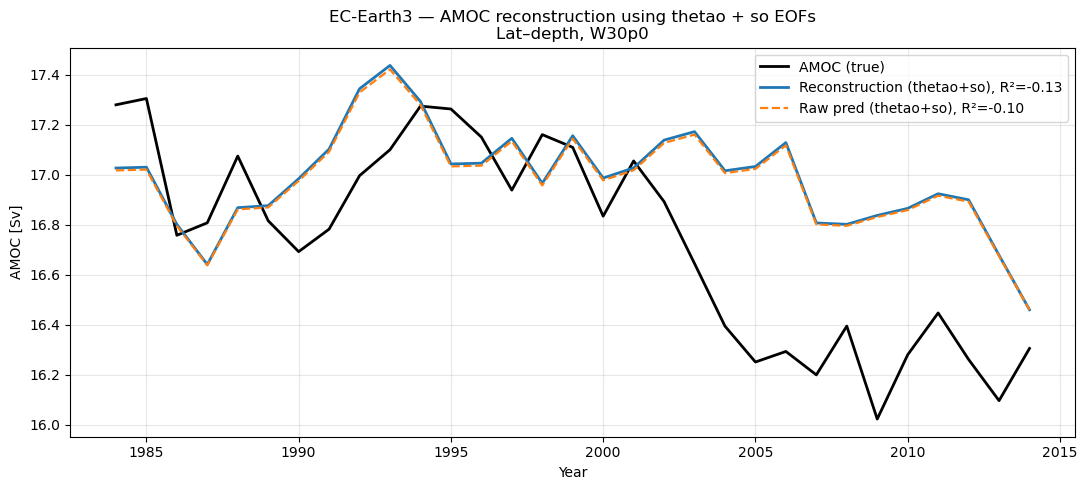

Saved: /data/users/frekle/AMOC_reconstruction/Lat_depth/AMOC_45N_ensmean/EC-Earth3/thetao_so/EC-Earth3_thetao_so_AMOC_45N_ensmean_latdepth_W30p0_T10_S10_L10_timeseries.png


In [35]:
#!/usr/bin/env python3
# ============================================================
# PLOT AMOC RECONSTRUCTION — TWO VARIABLES (thetao + so)
# UPDATED to match the new multivariate reconstruction outputs
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import os

# ============================================================
# CONFIG
# ============================================================

MODEL   = "EC-Earth3"   # "IPSL-CM6A-LR", "MPI-ESM1-2-LR", "EC-Earth3", ...
TARGET  = "AMOC_45N_ensmean"
LON_TAG = "W30p0"

N_MODES = 10
N_LAGS  = 10
v1 = "thetao"
v2 = "so"

BASE   = "/data/users/frekle/AMOC_reconstruction/Lat_depth"
PREFIX = f"{BASE}/{TARGET}/{MODEL}/{v1}_{v2}/{MODEL}_{v1}_{v2}_{TARGET}_latdepth_{LON_TAG}_T{N_MODES}_S{N_MODES}_L{N_LAGS}"

OUTPNG = PREFIX + "_timeseries.png"

# ============================================================
# LOAD DATA (new naming)
# ============================================================

Y_true = np.load(PREFIX + "_Ytrue.npy").squeeze().ravel()
time   = np.load(PREFIX + "_time.npy").squeeze().ravel()

# Main prediction (may be calibrated if enabled)
Y_pred = np.load(PREFIX + "_Ypred.npy").squeeze().ravel()

# Raw prediction (if present)
raw_path = PREFIX + "_Ypred_raw.npy"
has_raw = os.path.exists(raw_path)
Y_pred_raw = np.load(raw_path).squeeze().ravel() if has_raw else None

# Optional: calibration params
cal_path = PREFIX + "_calibration_ab.npy"
has_cal = os.path.exists(cal_path)
cal_ab = np.load(cal_path) if has_cal else None

# Optional: meta
meta_path = PREFIX + "_meta.npy"
meta = np.load(meta_path) if os.path.exists(meta_path) else None

# ============================================================
# METRICS
# ============================================================

def r2(y, yhat):
    y = np.asarray(y).squeeze().ravel()
    yhat = np.asarray(yhat).squeeze().ravel()
    ybar = y.mean()
    ss_tot = np.sum((y - ybar)**2)
    ss_res = np.sum((y - yhat)**2)
    return 1 - ss_res/ss_tot if ss_tot != 0 else np.nan

def corr(y, yhat):
    y = np.asarray(y).squeeze().ravel()
    yhat = np.asarray(yhat).squeeze().ravel()
    if np.std(y) == 0 or np.std(yhat) == 0:
        return np.nan
    return float(np.corrcoef(y, yhat)[0, 1])

R2_main = r2(Y_true, Y_pred)
r_main  = corr(Y_true, Y_pred)

R2_raw = r_raw = None
if Y_pred_raw is not None:
    R2_raw = r2(Y_true, Y_pred_raw)
    r_raw  = corr(Y_true, Y_pred_raw)

# ============================================================
# PRINT SUMMARY
# ============================================================

print("PREFIX:", PREFIX)
print("len:", len(Y_true))

print("\nTrue:")
print("  std:", float(np.std(Y_true)))
print("  min/max:", float(np.min(Y_true)), float(np.max(Y_true)))

print("\nPred (MAIN):")
print("  std:", float(np.std(Y_pred)))
print("  min/max:", float(np.min(Y_pred)), float(np.max(Y_pred)))
print(f"  R²={R2_main:.3f}  corr={r_main:.3f}")

if Y_pred_raw is not None:
    print("\nPred (RAW):")
    print("  std:", float(np.std(Y_pred_raw)))
    print("  min/max:", float(np.min(Y_pred_raw)), float(np.max(Y_pred_raw)))
    print(f"  R²={R2_raw:.3f}  corr={r_raw:.3f}")

if meta is not None:
    # meta saved as [alpha_best, raw_r2, cal_flag] (older) or similar
    print("\nmeta:", meta)

if has_cal:
    print("Calibration (a,b):", cal_ab)

# Extra SS diagnostics (main)
ss_res = np.sum((Y_true - Y_pred) ** 2)
ss_tot = np.sum((Y_true - np.mean(Y_true)) ** 2)
print("\nSS diagnostics (MAIN):")
print("  SS_res:", float(ss_res))
print("  SS_tot:", float(ss_tot))
print("  SS_res/SS_tot:", float(ss_res/ss_tot) if ss_tot != 0 else np.nan)

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(11, 5))

plt.plot(time, Y_true, color="black", lw=2, label="AMOC (true)")

# Main prediction (maybe calibrated)
plt.plot(time, Y_pred, lw=2,
         label=f"Reconstruction ({v1}+{v2}), R²={R2_main:.2f}")

# Overlay raw if present
if Y_pred_raw is not None:
    plt.plot(time, Y_pred_raw, lw=1.6, linestyle="--",
             label=f"Raw pred ({v1}+{v2}), R²={R2_raw:.2f}")

plt.xlabel("Year")
plt.ylabel("AMOC [Sv]")
plt.title(f"{MODEL} — AMOC reconstruction using {v1} + {v2} EOFs\nLat–depth, {LON_TAG}")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPNG, dpi=300)
plt.show()

print("Saved:", OUTPNG)

In [19]:
#!/usr/bin/env python3
# ============================================================
# DIAGNOSTICS — AMOC reconstruction saved outputs (ROBUST)
# Handles shape issues by forcing arrays to 1D.
# ============================================================

import numpy as np
import os

# ----------------------------
# CONFIG
# ----------------------------
MODEL   = "EC-Earth3"
TARGET  = "AMOC_45N_ensmean"
LON_TAG = "W30p0"

BASE   = "/data/users/frekle/AMOC_reconstruction/Lat_depth"
PREFIX = f"{BASE}/{TARGET}/{MODEL}/thetao_so/{MODEL}_thetao_so_{TARGET}_latdepth_{LON_TAG}_T10_S10_L10"

def hdr(s):
    print("\n" + "="*70)
    print(s)
    print("="*70)

def to_1d(a, name):
    a = np.asarray(a)
    print(f"{name}: raw shape={a.shape}, dtype={a.dtype}")
    # squeeze removes size-1 dims; ravel makes it 1D
    a1 = np.squeeze(a).ravel()
    print(f"{name}: 1D  shape={a1.shape}")
    return a1

def r2_components(y, yhat):
    ybar = np.mean(y)
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - ybar) ** 2)
    r2 = 1.0 - ss_res/ss_tot if ss_tot != 0 else np.nan
    return r2, ss_res, ss_tot, ss_res/ss_tot if ss_tot != 0 else np.nan

def safe_corr(y, yhat):
    # assumes 1D same length
    if len(y) < 2 or np.std(y) == 0 or np.std(yhat) == 0:
        return np.nan
    return float(np.corrcoef(y, yhat)[0, 1])

# ----------------------------
# LOAD
# ----------------------------
hdr("LOADING FILES")
y_true_raw = np.load(PREFIX + "_Ytrue.npy", allow_pickle=True)
y_pred_raw = np.load(PREFIX + "_Ypred.npy", allow_pickle=True)
time_raw   = np.load(PREFIX + "_time.npy",  allow_pickle=True)

coef_path = PREFIX + "_coef.npy"
coef_raw  = np.load(coef_path, allow_pickle=True) if os.path.exists(coef_path) else None

# ----------------------------
# FORCE 1D
# ----------------------------
hdr("SHAPE NORMALIZATION (force 1D)")
y_true = to_1d(y_true_raw, "y_true")
y_pred = to_1d(y_pred_raw, "y_pred")
time   = to_1d(time_raw,   "time")

# ----------------------------
# LENGTH CHECK
# ----------------------------
hdr("LENGTH CHECK")
print("len(y_true):", len(y_true))
print("len(y_pred):", len(y_pred))
print("len(time)  :", len(time))

L = min(len(y_true), len(y_pred), len(time))
if not (len(y_true) == len(y_pred) == len(time)):
    print("\n!! WARNING: lengths differ. Truncating all to min length:", L)
    y_true = y_true[:L]
    y_pred = y_pred[:L]
    time   = time[:L]

# ----------------------------
# NAN/INF CHECK
# ----------------------------
hdr("NAN / INF CHECKS")
print("y_true NaN?", np.isnan(y_true).any(), "Inf?", np.isinf(y_true).any())
print("y_pred NaN?", np.isnan(y_pred).any(), "Inf?", np.isinf(y_pred).any())

# ----------------------------
# SUMMARY STATS
# ----------------------------
hdr("SUMMARY STATS")
print("y_true mean/std:", float(np.mean(y_true)), float(np.std(y_true)))
print("y_pred mean/std:", float(np.mean(y_pred)), float(np.std(y_pred)))
print("y_true min/max :", float(np.min(y_true)), float(np.max(y_true)))
print("y_pred min/max :", float(np.min(y_pred)), float(np.max(y_pred)))

# ----------------------------
# METRICS
# ----------------------------
hdr("METRICS")
r2, ss_res, ss_tot, ratio = r2_components(y_true, y_pred)
print(f"R²: {r2:.6f}")
print(f"SS_res: {ss_res:.6f}")
print(f"SS_tot: {ss_tot:.6f}")
print(f"SS_res/SS_tot: {ratio:.6f}")

ybar = np.mean(y_true)
mse_model = np.mean((y_true - y_pred) ** 2)
mse_mean  = np.mean((y_true - ybar) ** 2)
print(f"MSE(model): {mse_model:.6f}")
print(f"MSE(mean) : {mse_mean:.6f}")
print(f"MSE ratio (model/mean): {mse_model/mse_mean:.6f}" if mse_mean != 0 else "MSE(mean)=0")

r = safe_corr(y_true, y_pred)
print(f"corr r: {r:.6f}")

# ----------------------------
# TIME CHECKS
# ----------------------------
hdr("TIME CHECKS")
print("time dtype:", time.dtype)
print("first 10 time entries:", time[:10])
try:
    t_float = time.astype(float)
    diffs = np.diff(t_float)
    print("time strictly increasing?", bool(np.all(diffs > 0)))
    if not np.all(diffs > 0):
        bad = np.where(diffs <= 0)[0]
        print("Indices where time step <= 0 (up to 10):", bad[:10])
except Exception as e:
    print("Could not convert time to float for sorting checks:", e)

# ----------------------------
# OUTLIERS
# ----------------------------
hdr("ERROR OUTLIERS")
err = y_true - y_pred
abs_err = np.abs(err)

print("MAE :", float(np.mean(abs_err)))
print("RMSE:", float(np.sqrt(np.mean(err**2))))
print("Max |err|:", float(np.max(abs_err)))

k = min(10, len(y_true))
worst = np.argsort(abs_err)[-k:][::-1]
print(f"\nTop {k} worst points:")
for idx in worst:
    # year printing
    try:
        yr = int(float(time[idx]))
    except Exception:
        yr = time[idx]
    print(f"  year={yr:>6} | true={float(y_true[idx]):>10.4f} | pred={float(y_pred[idx]):>10.4f} | "
          f"err={float(err[idx]):>10.4f} | |err|={float(abs_err[idx]):>10.4f}")

# ----------------------------
# OPTIONAL COEF
# ----------------------------
if coef_raw is not None:
    hdr("COEFFICIENTS (optional)")
    coef = np.squeeze(np.asarray(coef_raw))
    print("coef raw shape:", np.asarray(coef_raw).shape, "-> squeezed:", coef.shape)
    flat = coef.ravel()
    print("coef min/max:", float(np.min(flat)), float(np.max(flat)))
    print("coef L2 norm:", float(np.linalg.norm(flat)))
    kk = min(10, flat.size)
    top = np.argsort(np.abs(flat))[-kk:][::-1]
    print(f"\nTop {kk} |coef| values:")
    for j in top:
        print(f"  idx={j:>6} | coef={float(flat[j]): .6e}")

hdr("DONE")
print("If R² is hugely negative, check the 'Top worst points' section.")



LOADING FILES

SHAPE NORMALIZATION (force 1D)
y_true: raw shape=(31,), dtype=float32
y_true: 1D  shape=(31,)
y_pred: raw shape=(31,), dtype=float32
y_pred: 1D  shape=(31,)
time: raw shape=(31,), dtype=int64
time: 1D  shape=(31,)

LENGTH CHECK
len(y_true): 31
len(y_pred): 31
len(time)  : 31

NAN / INF CHECKS
y_true NaN? False Inf? False
y_pred NaN? False Inf? False

SUMMARY STATS
y_true mean/std: 16.738847732543945 0.3920740783214569
y_pred mean/std: 16.985776901245117 0.20095965266227722
y_true min/max : 16.023759841918945 17.305513381958008
y_pred min/max : 16.460935592651367 17.437889099121094

METRICS
R²: -0.127925
SS_res: 5.374994
SS_tot: 4.765384
SS_res/SS_tot: 1.127925
MSE(model): 0.173387
MSE(mean) : 0.153722
MSE ratio (model/mean): 1.127925
corr r: 0.518417

TIME CHECKS
time dtype: int64
first 10 time entries: [1984 1985 1986 1987 1988 1989 1990 1991 1992 1993]
time strictly increasing? True

ERROR OUTLIERS
MAE : 0.3403245210647583
RMSE: 0.4163975417613983
Max |err|: 0.8352317

In [20]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

y = y_true.reshape(-1,1)
x = y_pred.reshape(-1,1)

lr = LinearRegression().fit(x, y)
y_cal = lr.predict(x).ravel()

print("a (intercept):", lr.intercept_[0])
print("b (slope)    :", lr.coef_[0,0])
print("R2 original  :", r2_score(y_true, y_pred))
print("R2 calibrated:", r2_score(y_true, y_cal))
print("corr r       :", np.corrcoef(y_true, y_pred)[0,1])


a (intercept): -0.44117546
b (slope)    : 1.0114359
R2 original  : -0.12792456150054932
R2 calibrated: 0.2687561511993408
corr r       : 0.51841685179615
